# CE 310 — Week 9 In-Class Exercise: Simple Linear Regression
## From Correlation to Prediction

**Dataset:** DOE Reference Medium Office Building, Tucson/Phoenix Climate Zone 2B  
**Tools:** pandas · matplotlib · scipy.stats  
**Submission:** Download as .ipynb (File → Download → Download .ipynb) and submit to D2L

---

**Grading — 100 pts**

| Section | Items | Points |
|---|---|---|
| A — describe the data | 8 numeric | 16 |
| B — fit and use the model | 12 numeric | 60 |
| Written: B3 interpretation, B7 plot, B8 plot | 3 × 4 | 12 |
| Technical memo | 1 | 12 |
| **Total** | | **100** |


## Before You Begin

**New to Python?** Work through an introductory Colab and pandas primer first (about 15 minutes). This module assumes you can open a notebook, run a cell, and select a DataFrame column.

**File needed:** `Week5_DOE_MedOffice_ZoneTemp_2023.csv`  
This is the same dataset you used in Week 7.  

**Upload options:**
1. **Colab Files panel (easiest):** Click the folder icon in the left sidebar → click the upload icon → select the CSV file from your computer.
2. **Google Drive mount:** If your file is already in Google Drive, click the Drive mount button in the Files panel and navigate to the file.

> If you see `FileNotFoundError`, the CSV is not in Colab's working directory — go back and upload it first.

## Background

A mechanical engineer sized a chiller using the annual average outdoor temperature. In Week 1 you proved that **averages fail for peak design** — the average cannot tell you how often the system is stressed. But averages also fail for *prediction*. If you want to estimate cooling demand on a specific day, the average gives you the same answer every day regardless of conditions. 

Today you build a regression model that **actually varies with outdoor temperature**.

| Design Decision | Wrong approach | What you need |
|---|---|---|
| Estimate hourly cooling energy | Use annual average (≈19 kWh/hr regardless of weather) | Predict from outdoor temperature: ŷ = β₀ + β₁·x |
| Validate model quality | "It seems to fit" | Quantify: R² = fraction of variance explained |
| Size for peak cooling day | Predict from mean temperature | Predict from 99th-percentile design temperature |

**Machine learning bridge:** Linear regression is the foundation of supervised learning. Every neural network and gradient boosting model is solving a generalized version of what you do today: *find the function that minimizes prediction error on training data.* The difference is that those models learn more complex, non-linear functions — but the core principle (minimize residuals) is identical.

In [ ]:
# ── Identify your submission ─────────────────────────────────────────
# Fill both in before you run anything else. NETID is what matches your
# work to your student record — a blank NETID takes a 5-point deduction.
NAME  = ""   # e.g. "Jordan Reyes"
NETID = ""   # e.g. "jreyes"

print(f"NAME  = {NAME}")
print(f"NETID = {NETID}")

In [ ]:
# ── What each library does ─────────────────────────────────────────────
# pandas (pd)  — loads and manipulates tabular data (like Excel, but in Python)
# numpy (np)   — fast math on arrays of numbers
# matplotlib   — creates charts and plots
# scipy.stats  — statistical functions including linregress

# ── SETUP: run this first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset (upload Week5_DOE_MedOffice_ZoneTemp_2023.csv first)
df = pd.read_csv('Week5_DOE_MedOffice_ZoneTemp_2023.csv')

print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(df.dtypes)
df.head(3)

## Picking Up From Week 7

In Week 7 you computed **r(Outdoor_Temp_F, Cooling_kWh) ≈ 0.78** using Excel's CORREL function. A strong positive correlation — but correlation only tells you the *strength* of the linear relationship. Today you build the actual predictive equation:

> **How many kWh does cooling demand increase for each 1°F rise in outdoor temperature?**

That is the slope β₁ — and it is the number an engineer needs to size equipment and estimate energy costs.

---
## Section A: Exploratory Analysis (~25 min)

Before building a model, always explore the data. Section A confirms you understand the dataset structure and the key statistics you will need to interpret the regression results.

*For each question, replace `___` with the correct value or expression. Print statements are already written — just fill in the blanks.*

**Python reminder:** `df['column_name']` accesses a column. `.mean()`, `.std()`, `.min()`, `.max()`, `.median()` all work the same way. Round with `round(expression, decimal_places)`.

In [ ]:
# ── A1 ────────────────────────────────────────────────────────────────
# How many hourly observations are in this dataset?

ANSWER_A1 = ___   # fill in: the number of rows

print(f"ANSWER_A1 = {ANSWER_A1}")

In [ ]:
# ── A2 ────────────────────────────────────────────────────────────────
# What is the mean outdoor temperature (°F)? Round to 2 decimal places.

ANSWER_A2 = round(___, 2)   # fill in: the mean outdoor temperature

print(f"ANSWER_A2 = {ANSWER_A2} °F")

In [ ]:
# ── A3 ────────────────────────────────────────────────────────────────
# What is the standard deviation of Cooling_kWh? Round to 2 decimal places.

ANSWER_A3 = round(___, 2)   # fill in: the spread of Cooling_kWh

print(f"ANSWER_A3 = {ANSWER_A3} kWh")

In [ ]:
# ── A4 ────────────────────────────────────────────────────────────────
# What is the minimum value of Cooling_kWh?
#
# Physical interpretation: a minimum of 0 kWh means the chiller is completely
# off — no mechanical cooling is needed (typically on cold nights or mild days).

ANSWER_A4 = ___   # fill in: the smallest Cooling_kWh value

print(f"ANSWER_A4 = {ANSWER_A4} kWh")

In [ ]:
# ── A5 ────────────────────────────────────────────────────────────────
# What is the maximum Cooling_kWh in any single hour?

ANSWER_A5 = ___   # fill in: the largest Cooling_kWh in one hour

print(f"ANSWER_A5 = {ANSWER_A5} kWh")

In [ ]:
# ── A6 ────────────────────────────────────────────────────────────────
# What is the median Cooling_kWh? Round to 2 decimal places.
#
# Note: Is the median less than, equal to, or greater than the mean?
# Why? (Hint: most hours have Cooling_kWh = 0; the distribution is right-skewed
# with a small number of very high-demand hours pulling the mean upward.)

ANSWER_A6 = round(___, 2)   # fill in: the median Cooling_kWh

print(f"ANSWER_A6 = {ANSWER_A6} kWh")

In [ ]:
# ── A7 ────────────────────────────────────────────────────────────────
# Compute the Pearson correlation r between Outdoor_Temp_F and Cooling_kWh.
# Round to 4 decimal places.
#
# You should recognize this value — you computed it in Week 7 using Excel CORREL.

ANSWER_A7 = round(___, 4)   # fill in: r between the two columns

print(f"ANSWER_A7 = {ANSWER_A7}")
print("(Check: does this match your Week 7 CORREL result?)")

In [ ]:
# ── A8 ────────────────────────────────────────────────────────────────
# How many hours have Cooling_kWh > 0? (i.e., how often is the chiller actually running?)

ANSWER_A8 = ___   # fill in: the count of hours with cooling above zero

print(f"ANSWER_A8 = {ANSWER_A8} hours")
print(f"Fraction of year with cooling active: {ANSWER_A8 / 8760:.1%}")

---
## Section B: Regression Analysis

Section A described what the data looks like. Section B fits a line to it and asks what the line is worth: the slope becomes a design number — how much chiller capacity each degree of outdoor temperature buys you — R² says how much of the variation that line accounts for, and the residual plot says whether a line was the right shape to begin with. The section ends by predicting cooling at a design temperature the building has never actually experienced, which is where a fitted model either earns its keep or quietly misleads you.

**Target shape for B1:**

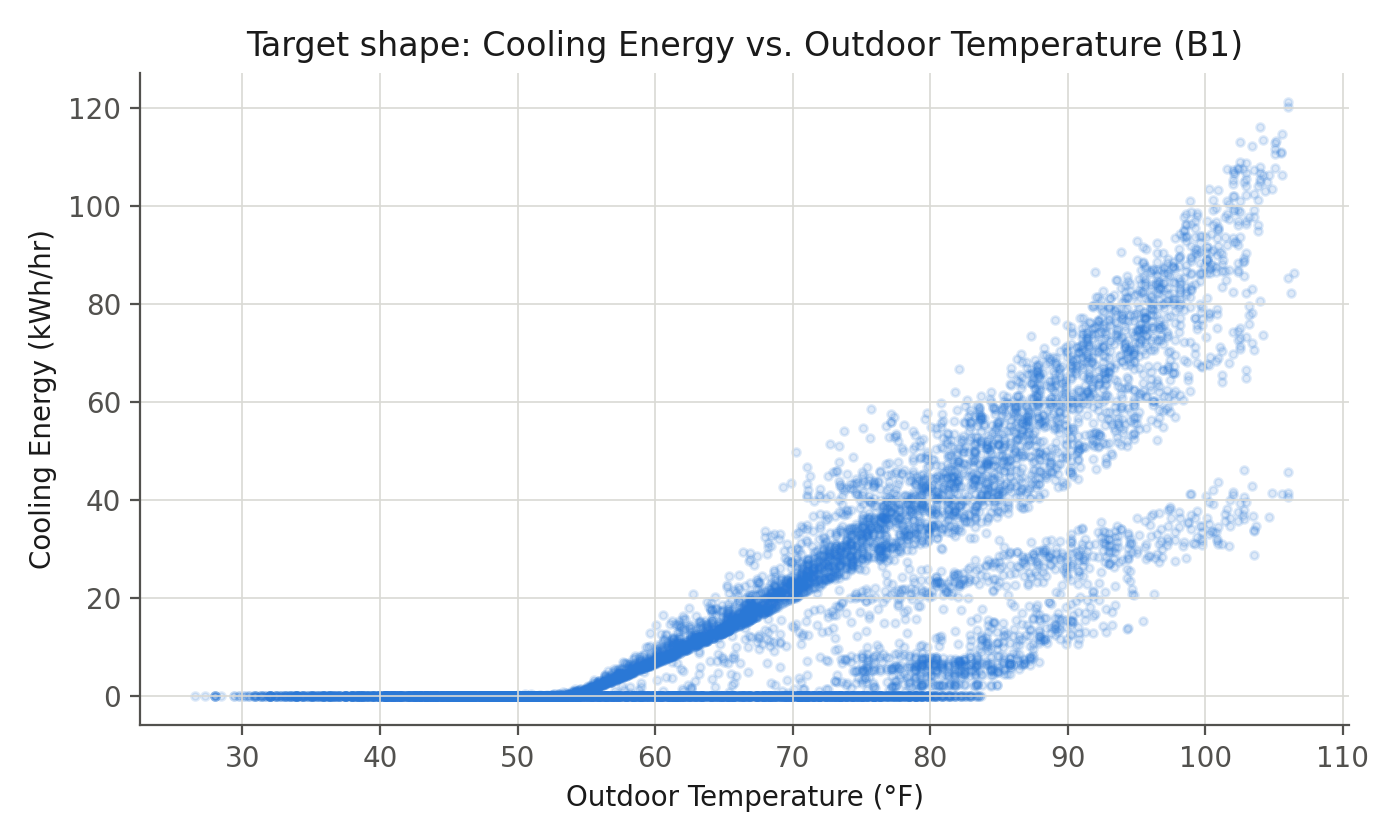


In [ ]:
# ── B1: Scatter plot ──────────────────────────────────────────────────
# First, visualize the relationship before fitting any model.

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Outdoor_Temp_F'], df['Cooling_kWh'],
           alpha=0.15, s=5, color='steelblue')
ax.set_xlabel(___)   # fill in: axis label with units
ax.set_ylabel(___)   # fill in: axis label with units
ax.set_title(___)    # fill in: a title naming both variables and the building
plt.tight_layout()
plt.show()

In [ ]:
# ── B2: Linear regression ─────────────────────────────────────────────
# Fit a simple linear regression: Cooling_kWh ~ Outdoor_Temp_F
# Fill in the column names for x (predictor) and y (outcome).

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df[___],   # fill in: the predictor column name
    df[___]    # fill in: the outcome column name
)

print(f"Slope:      {slope:.4f}  kWh/°F")
print(f"Intercept:  {intercept:.4f}  kWh")
print(f"r:          {r_value:.4f}")
print(f"r²:         {r_value**2:.4f}")
print(f"p-value:    {p_value:.2e}")

In [ ]:
# ── B3 ★: Slope — record and interpret ───────────────────────────────
# The slope is the most important engineering output from this model.
# Record it here; then fill in the Markdown cell below with an interpretation.

ANSWER_B3_slope = round(slope, 3)

print(f"ANSWER_B3_slope = {ANSWER_B3_slope} kWh/°F")

# ── B3b: Standard error of the slope ─────────────────────────────────
# linregress already returned this. It is the uncertainty on the slope:
# roughly, the slope is 1.158 ± 2×std_err at 95% confidence.

ANSWER_B3_slope_se = round(std_err, 4)

print(f"ANSWER_B3_slope_se = {ANSWER_B3_slope_se} kWh/°F")


**B3 Interpretation (fill in):**

For every 1°F increase in outdoor temperature, cooling demand increases by ___ kWh/hr.

This means a design day that is ___ °F above the annual average outdoor temperature would require approximately ___ kWh/hr more cooling capacity than a model based solely on the average would predict.

In [ ]:
# ── B4: Intercept ─────────────────────────────────────────────────────
# Record the intercept.
# Note: the intercept is the predicted cooling when outdoor temp = 0°F.
# Is this physically meaningful for Tucson? (It will be negative — why?)

ANSWER_B4_intercept = round(intercept, 2)

print(f"ANSWER_B4_intercept = {ANSWER_B4_intercept} kWh")
print("(A negative intercept is expected: the model is only valid in the range of observed temperatures.")
print(" Outdoor temp = 0°F never occurs in Tucson, so extrapolating there is not physically meaningful.)")

In [ ]:
# ── B5: R² ────────────────────────────────────────────────────────────
# Record R² (coefficient of determination).
# R² = fraction of variance in Cooling_kWh explained by Outdoor_Temp_F.

ANSWER_B5_r2 = round(r_value**2, 4)

print(f"ANSWER_B5_r2 = {ANSWER_B5_r2}")
print(f"Interpretation: outdoor temperature explains {ANSWER_B5_r2*100:.1f}% of the variance in cooling energy.")

In [ ]:
# ── B6: Statistical significance ──────────────────────────────────────
# Is the regression statistically significant?
# Fill in True or False: is the p-value less than 0.05?

ANSWER_B6_significant = ___   # fill in: True or False

print(f"ANSWER_B6_significant = {ANSWER_B6_significant}")
print(f"p-value = {p_value:.2e}")
print("(p < 0.05 means we reject H₀: β₁ = 0 — the slope is statistically significant.)")


*p-value context (ungraded): The p-value for the regression tests H₀: slope = 0 (no linear relationship between outdoor temperature and cooling load). With n = 8,760 and a slope of ≈ 1.16 kWh/°F, the p-value is effectively 0 — so small that floating-point underflow represents it as 0.0 in most outputs. A statistically significant regression does not mean the model is accurate enough for design; it means the slope is almost certainly non-zero. You still need to check R² and the residual plot before trusting predictions.*


---

**Target shape for B7:**

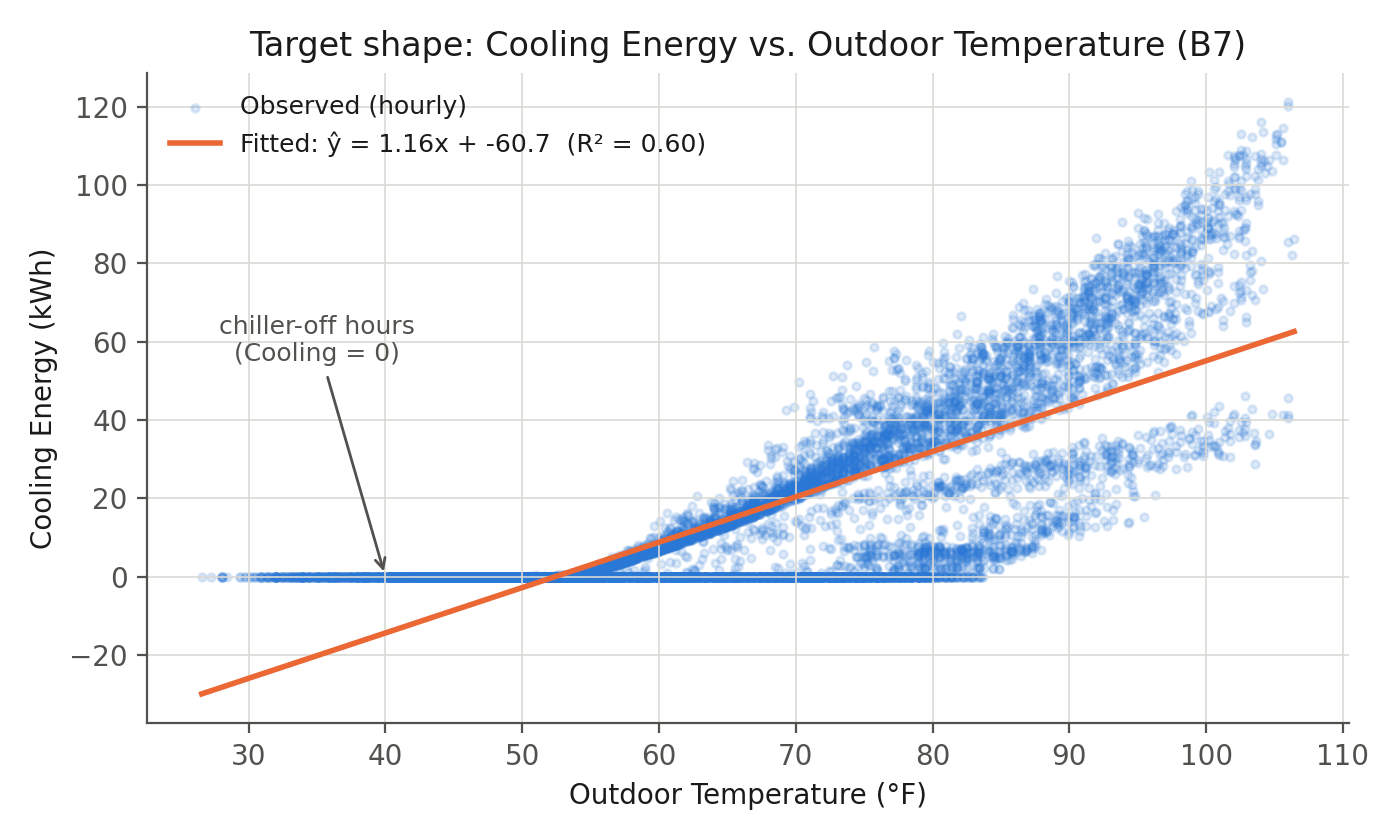


In [ ]:
# ── B7: Regression line on scatter plot ──────────────────────────────
# Plot the fitted regression line on top of the scatter plot.
# Fill in the axis labels and title (same as B1, but now with the regression line added).

x_line = np.linspace(df['Outdoor_Temp_F'].min(), df['Outdoor_Temp_F'].max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Outdoor_Temp_F'], df['Cooling_kWh'],
           alpha=0.15, s=5, color='steelblue', label='Observed')
ax.plot(x_line, y_line, color='red', linewidth=2,
        label=f'ŷ = {slope:.3f}x + {intercept:.2f}')
ax.set_xlabel(___)   # fill in: axis label with units
ax.set_ylabel(___)   # fill in: axis label with units
ax.set_title(___)    # fill in: a title naming both variables
ax.legend()
plt.tight_layout()
plt.show()

**Target shape for B8:**

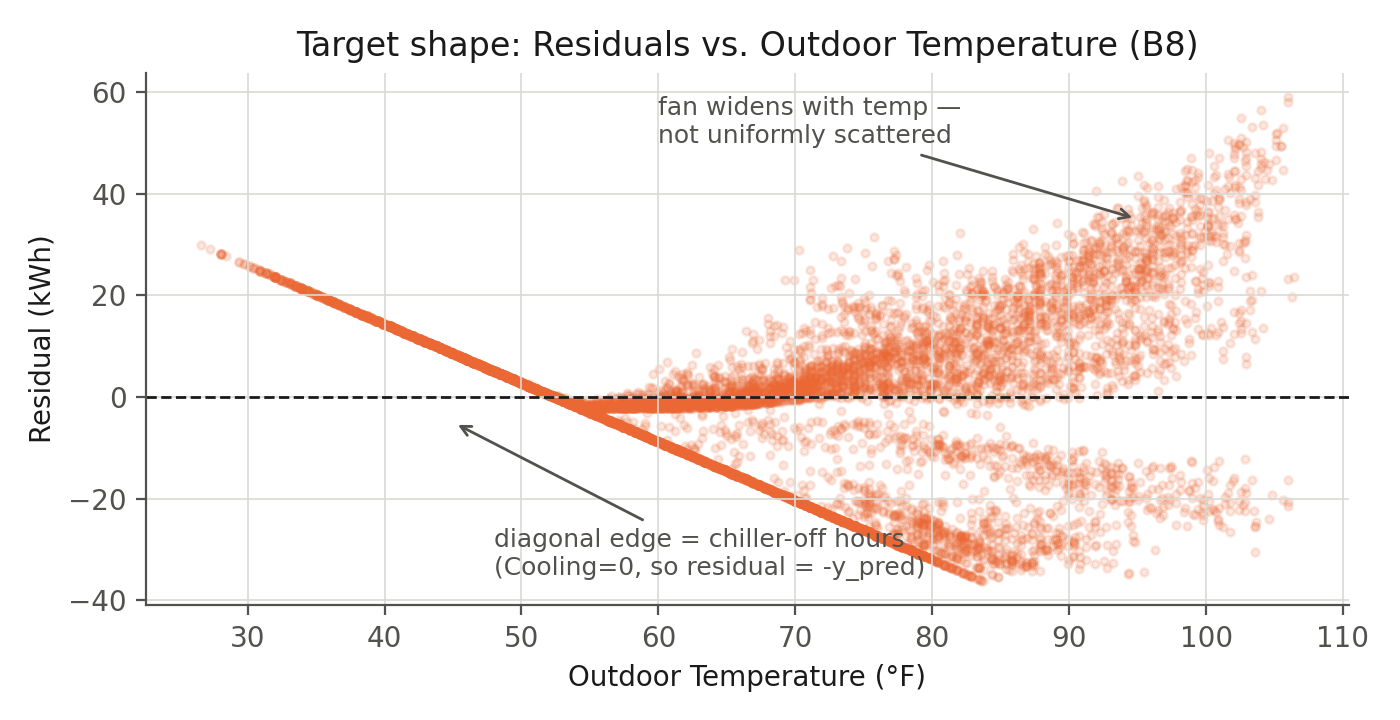


In [ ]:
# ── B8: Residual plot ─────────────────────────────────────────────────
# Plot residuals (observed − predicted) vs. outdoor temperature.
# A good model shows residuals scattered randomly around zero with no pattern.
# Fill in the x-axis label and title.

y_pred = slope * df['Outdoor_Temp_F'] + intercept
residuals = df['Cooling_kWh'] - y_pred

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Outdoor_Temp_F'], residuals,
           alpha=0.15, s=5, color='orange')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel(___)   # fill in: the x-axis label with units
ax.set_ylabel('Residual (kWh/hr)')
ax.set_title(___)    # fill in: a title naming the plot and the model
plt.tight_layout()
plt.show()

# Observation prompt: at outdoor temps below ~45°F, what do you notice about the residuals?
# (They are all positive — the model over-predicts cooling at cold temperatures.
#  Why? Because the chiller is off (Cooling_kWh = 0) but the model predicts negative values,
#  which are clipped to 0 in reality. This is the model's largest structural limitation.)

# ── B8b/B8c: Residual summary statistics ─────────────────────────────
# The plot above shows the residuals; these two numbers summarize it.
# The mean is ~0 by construction — OLS forces it. The standard deviation
# is the residual standard error: how far a typical prediction misses.

ANSWER_B8_resid_mean = round(residuals.mean(), 4)
ANSWER_B8_resid_std  = round(residuals.std(), 2)

print(f"ANSWER_B8_resid_mean = {ANSWER_B8_resid_mean}")
print(f"ANSWER_B8_resid_std = {ANSWER_B8_resid_std} kWh/hr")



*LINE assumptions check (ungraded): A valid linear regression requires four conditions (LINE): **L**inear relationship, **I**ndependent errors, **N**ormally distributed residuals, **E**qual variance (homoscedasticity). Your residual plot lets you check three of them: (1) if residuals fan out at higher temperatures, equal variance fails; (2) if the residuals show a curve, the linear assumption fails; (3) with 8,760 hourly observations, independent errors is the toughest to satisfy — consecutive hours share weather, so residuals at 3 AM and 4 AM are correlated. The regression is still useful, but confidence intervals computed assuming independence will be too narrow. Week 14 bootstrap addresses this partially.*


In [ ]:
# ── B9 CE track: Predict cooling at the 1% design temperature ─────────
# From Week 1, the 1% cooling design temperature ≈ 108°F
# (ASHRAE LARGE(data, 88) for 8,760 annual hours → top 1% threshold)
# Use your regression model to predict cooling demand at this design condition.

design_temp_CE = 108.0   # °F  (ASHRAE 1% cooling design condition)

ANSWER_B9_CE = round(slope * design_temp_CE + intercept, 1)

print(f"ANSWER_B9_CE = {ANSWER_B9_CE} kWh/hr at {design_temp_CE}°F")
print(f"Compare to annual mean cooling: {df['Cooling_kWh'].mean():.1f} kWh/hr")
print(f"Peak-to-mean ratio: {ANSWER_B9_CE / df['Cooling_kWh'].mean():.2f}×")

# ── B9b: The same model read at the annual mean ──────────────────────
# This is the week's argument in one line. Predict at the annual mean
# outdoor temperature and compare to the design-day answer above.

mean_temp = df['Outdoor_Temp_F'].mean()

ANSWER_B9_mean_temp = round(slope * mean_temp + intercept, 2)

print(f"ANSWER_B9_mean_temp = {ANSWER_B9_mean_temp} kWh/hr at {mean_temp:.1f}°F")



*Refrigeration tons (ungraded): Chiller capacity is often specified in **tons of refrigeration** rather than kWh/hr. 1 ton = 3.517 kWh/hr (it is the heat flux required to melt one short ton of ice in 24 hours). To convert your model prediction in kWh/hr to tons, divide by 3.517. For example, a predicted 100 kWh/hr ≈ 28.4 tons — a common small commercial chiller size. Knowing both units is essential when reading equipment schedules and ASHRAE load calculations.*


In [ ]:
# ── B10 ArcE track: Predict cooling at the economizer cutoff temperature ──
# ASHRAE 90.1 economizer high-limit cutoff for Climate Zone 2B ≈ 75°F.
# Below this outdoor temperature, outside air provides "free cooling."
# Above it, mechanical cooling is required.

neutral_temp = 75.0   # °F  (ASHRAE 90.1 economizer cutoff, Climate Zone 2B)

ANSWER_B10_ArcE = round(slope * neutral_temp + intercept, 1)

print(f"ANSWER_B10_ArcE = {ANSWER_B10_ArcE} kWh/hr at {neutral_temp}°F")
print(f"Note: positive value confirms mechanical cooling is needed above the economizer threshold.")

# ── B10b: Capacity between the economizer cutoff and the design day ──
# The difference between the two predictions is the mechanical cooling
# the plant has to add once free cooling stops being available.

ANSWER_B10_gap = round(ANSWER_B9_CE - ANSWER_B10_ArcE, 2)

print(f"ANSWER_B10_gap = {ANSWER_B10_gap} kWh/hr")


In [ ]:
# ── B11: Compare r to Week 7 Excel result ─────────────────────────────
# In Week 7 you computed r using Excel CORREL. Today you computed r using scipy.
# They should agree to at least 3 decimal places — both are Pearson correlation.

week7_correl = 0.7752   # your Week 7 result from Excel CORREL (update if yours differed)

ANSWER_B11_difference = abs(round(r_value - week7_correl, 4))

print(f"Week 9 scipy r  = {r_value:.4f}")
print(f"Week 7 CORREL   = {week7_correl:.4f}")
print(f"Difference      = {ANSWER_B11_difference:.4f}")
print(f"ANSWER_B11_difference = {ANSWER_B11_difference}")
print()
if ANSWER_B11_difference < 0.001:
    print("✓ Difference < 0.001 — Excel and Python give the same result.")
else:
    print("⚠ Difference ≥ 0.001 — check your Week 7 CORREL column references.")

---
## Sidebar: Confidence Interval vs Prediction Interval

Your regression gives a **point estimate** (ŷ) — a single number. But engineers need to know *how uncertain* that estimate is. There are two kinds of intervals:

| Interval | Answers the question | Width |
|---|---|---|
| **CI for the mean** | Where does the mean load for ALL hours at this temperature fall? | Narrow — shrinks as n grows |
| **PI for a single observation** | Where might a SINGLE future hour at this temperature actually fall? | Wide — includes residual scatter |

**Why does this matter for equipment sizing?** If you size a chiller to the CI upper bound, roughly half of all future peak hours will exceed your capacity. Equipment sizing requires the **PI** — it captures the variability of individual observations, not just uncertainty about the mean.

This cell is a **demonstration — not graded**. Run it to see both intervals at the ASHRAE 1% design temperature.

In [ ]:
# ── B12 Demonstration: 95% CI vs PI at 108°F (not graded) ────────────────────
# Residual standard error: how far individual points scatter from the fitted line
y_fit      = slope * df['Outdoor_Temp_F'] + intercept
n          = len(df)
s_e        = np.sqrt(((df['Cooling_kWh'] - y_fit)**2).sum() / (n - 2))

x_new      = 108.0                                           # ASHRAE 1% design temp (°F)
x_mean     = df['Outdoor_Temp_F'].mean()
sum_sq_x   = ((df['Outdoor_Temp_F'] - x_mean)**2).sum()
y_hat      = slope * x_new + intercept

t_star     = stats.t.ppf(0.975, df=n - 2)                   # critical value for 95% two-tailed

# CI: uncertainty about where the TRUE MEAN line falls
# PI: uncertainty about where a SINGLE NEW OBSERVATION falls (adds residual scatter term)
se_mean    = s_e * np.sqrt(1/n + (x_new - x_mean)**2 / sum_sq_x)
se_obs     = s_e * np.sqrt(1 + 1/n + (x_new - x_mean)**2 / sum_sq_x)

ci_lo, ci_hi = round(y_hat - t_star * se_mean, 1), round(y_hat + t_star * se_mean, 1)
pi_lo, pi_hi = round(y_hat - t_star * se_obs,  1), round(y_hat + t_star * se_obs,  1)

print(f'Point estimate at {x_new}°F  : {y_hat:.1f} kWh/hr')
print()
print(f'95% CI for the MEAN prediction : ({ci_lo:>6.1f}, {ci_hi:>6.1f}) kWh/hr   width = {ci_hi - ci_lo:.1f}')
print(f'95% PI for a SINGLE observation: ({pi_lo:>6.1f}, {pi_hi:>6.1f}) kWh/hr   width = {pi_hi - pi_lo:.1f}')
print()
print('For equipment sizing → use the PI upper bound.')
print(f'Sizing to the CI upper bound ({ci_hi:.1f} kWh/hr) would leave you short during half of all peak hours.')


*Prediction interval (PI) engineering context (ungraded): The CI for the mean narrows as n grows large — with 8,760 observations, the CI is very tight. The PI does not narrow the same way; it always captures individual-hour variability. For engineering design, the PI is almost always the relevant interval: a chiller must handle individual peak-load hours, not the average of all hours at that temperature. Specifying a chiller at the CI upper bound would undersize it for the actual peak hours you care about.*


---
## Looking Ahead — Week 10

In Week 10 you will add a second predictor — `BusinessHours` — to ask:

> *After accounting for outdoor temperature, does occupancy explain additional variance in cooling energy?*

This is **multiple linear regression**: ŷ = β₀ + β₁·(Outdoor_Temp_F) + β₂·(BusinessHours)

Week 10 measures how much that second predictor adds, and asks whether the gain is large enough to justify carrying the extra term.

---
## Memo — Week 9

**To:** Building Engineer  
**From:** [Your Name]  
**Re:** Regression Model — Cooling Energy vs. Outdoor Temperature

---

**Paragraph 1 — Model Summary:**  
[Fill in: state the regression equation with actual slope and intercept values. State R². What fraction of cooling variance does outdoor temperature explain? What does that imply about factors not captured by this model?]

---

**Paragraph 2 — Engineering Interpretation:**  
[Fill in: what does the slope mean for equipment sizing? Compare the predicted cooling at the 1% design temperature (108°F) to the annual average cooling demand (~19 kWh/hr). By how much does the regression-based peak prediction exceed an average-based estimate? What is the practical consequence for chiller sizing?]

---

**Paragraph 3 — Model Limitations:**  
[Fill in: discuss one specific observation from the B8 residual plot. What pattern do you see at outdoor temperatures below ~45°F? Why does the linear model fail there? What physical phenomenon (chiller lockout, minimum load, nighttime setback) explains this pattern? Propose one modification to the modeling approach — for example, a piecewise model, a censored regression, or a seasonal sub-model — that would address this limitation.]

## Before You Submit

- [ ] `NAME` and `NETID` filled in at the top and showing in the cell output — a blank `NETID` takes a 5-point deduction
- [ ] Every cell run in order, top to bottom (Runtime → Run all) — no errors, no cell left unrun
- [ ] Every `ANSWER_` line prints a value, and no `print(f"ANSWER_... = ...")` line edited or deleted
- [ ] Memo paragraphs are filled in (not placeholder text)
- [ ] Downloaded as `.ipynb` — not PDF, not `.py`
- [ ] Renamed `CE310_W9_<NetID>.ipynb` and uploaded to the Week 9 D2L dropbox